In [1]:
import pandas as pd
import numpy as np
from tqdm.auto import tqdm
from src.processing import find_pareto_front, create_landscape_from_predictions#, history_to_dataframe
from src.visualization import (display_pareto_fronts3, 
                               display_fitness_landscape_with_2pareto, 
                               gerar_gif_evolucao_nsga2, 
                               display_evolution_of_genotypes, 
                               display_fitness_landscape_with_paretos)
from src.metrics import (calculate_gamma_convergence_metric, print_gamma_metric,
                         calculate_fitness_sum_statistics, print_fitness_sum_statistics,
                         calculate_delta_diversity_metric, print_delta_metric)

from src.nsgaII import run_my_nsga2
from src.ua_sa_nsgaII import run_my_uasa_nsga2

/Users/gmello/Documents/python_venvs/mestrado_estatistica/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
salva_gifs = False

# Inputs

In [11]:
df_mmf1_previsao   = pd.read_parquet('data/dataframes/MMF1/df_mmf1_previsao.parquet')
df_mmf4_previsao   = pd.read_parquet('data/dataframes/MMF4/df_mmf4_previsao.parquet')
df_bbob16_previsao = pd.read_parquet('data/dataframes/BBOB16/df_bbob16_previsao.parquet')

df_mmf1   = pd.read_parquet('data/dataframes/MMF1/df_mmf1.parquet')
df_mmf4   = pd.read_parquet('data/dataframes/MMF4/df_mmf4.parquet')
df_bbob16 = pd.read_parquet('data/dataframes/BBOB16/df_bbob16.parquet')

print(df_mmf1_previsao.shape)
print(df_mmf4_previsao.shape)

print(df_bbob16_previsao.shape)
display(df_bbob16_previsao.head())

(980000, 12)
(980000, 12)
(980000, 12)


,x_1,x_2,f1,f2,aux,bin_x1,bin_x2,regiao,f1_original,f2_original,f1_predicted,f2_predicted
0,-5.00000,-5.0,8.573109,5.373746,1,0,0,1,8.666895,5.831873,7.670689,5.414569
1,-4.98999,-5.0,9.818128,6.574159,1,0,0,1,8.665178,5.826707,7.670689,5.414569
2,-4.97998,-5.0,9.267276,6.838701,1,0,0,1,8.663448,5.821392,7.670689,5.414569
3,-4.96997,-5.0,7.803139,6.484946,1,0,0,1,8.661705,5.815924,7.670689,5.414569
4,-4.95996,-5.0,7.860431,6.419157,1,0,0,1,8.659949,5.810299,7.670689,5.414569


In [5]:
df_mcmc_mmf1 = pd.read_parquet('data/dataframes/MMF1/df_mmf1_mcmc.parquet').rename(columns={'index_linha': 'id_simulacao'})
df_mcmc_mmf4 = pd.read_parquet('data/dataframes/MMF4/df_mmf4_mcmc.parquet').rename(columns={'index_linha': 'id_simulacao'})
df_mcmc_bbob16 = pd.read_parquet('data/dataframes/BBOB16/df_bbob16_mcmc.parquet').rename(columns={'index_linha': 'id_simulacao'})

df_mcmc_mmf1.sort_values(['regiao', 'id_simulacao'], inplace=True)
df_mcmc_mmf4.sort_values(['regiao', 'id_simulacao'], inplace=True)
df_mcmc_bbob16.sort_values(['regiao', 'id_simulacao'], inplace=True)

config['n_simulations'] = df_mcmc_mmf1['id_simulacao'].max() + 1
print('n_simulations: ', config['n_simulations'])

print(df_mcmc_mmf1.shape)
print(df_mcmc_mmf4.shape)
print(df_mcmc_bbob16.shape)

df_mcmc_bbob16

n_simulations:  50
(800, 4)
(800, 4)
(800, 4)


,id_simulacao,regiao,erro_f1,erro_f2
0,0,1,-0.738709,-0.285201
1,1,1,2.278781,1.162943
2,2,1,1.250657,0.909852
3,3,1,-0.710681,-0.551601
4,4,1,2.205683,1.978901
...,...,...,...,...
795,45,9,0.291585,-0.098638
796,46,9,0.029411,0.020811
797,47,9,-0.760618,-0.430397
798,48,9,-0.664583,-0.375548


# Visualizando algoritmo

In [6]:
decision_variables = ['x_1', 'x_2']

df_landscape_bbob16 = create_landscape_from_predictions(
    df_previsao=df_bbob16_previsao,
    df_mcmc=df_mcmc_bbob16,
    decision_variables=decision_variables
)

print(df_landscape_bbob16.shape)
df_landscape_bbob16

(980000, 10)


,x_1,x_2,f1,f2,f1_original,f2_original,f1_predicted,f2_predicted,fitness1,fitness2
0,-5.0,-5.00000,8.573109,5.373746,8.666895,5.831873,7.670689,5.414569,"[6.932, 9.949, 8.921, 6.96, 9.876, 11.255, 7.8...","[5.129, 6.578, 6.324, 4.863, 7.393, 6.573, 5.4..."
1,-5.0,-4.98999,7.836290,5.360600,8.664149,5.827860,7.670689,5.414569,"[6.932, 9.949, 8.921, 6.96, 9.876, 11.255, 7.8...","[5.129, 6.578, 6.324, 4.863, 7.393, 6.573, 5.4..."
2,-5.0,-4.97998,10.878355,6.498595,8.661346,5.823767,7.670689,5.414569,"[6.932, 9.949, 8.921, 6.96, 9.876, 11.255, 7.8...","[5.129, 6.578, 6.324, 4.863, 7.393, 6.573, 5.4..."
3,-5.0,-4.96997,8.126955,6.574587,8.658486,5.819592,7.670689,5.414569,"[6.932, 9.949, 8.921, 6.96, 9.876, 11.255, 7.8...","[5.129, 6.578, 6.324, 4.863, 7.393, 6.573, 5.4..."
4,-5.0,-4.94995,11.189205,5.175324,8.652591,5.810999,8.116874,5.419707,"[7.378, 10.396, 9.368, 7.406, 10.323, 11.701, ...","[5.135, 6.583, 6.33, 4.868, 7.399, 6.578, 5.40..."
...,...,...,...,...,...,...,...,...,...,...
979995,5.0,4.95996,9.962616,5.166768,8.739325,5.842733,9.840034,5.146162,"[11.843, 8.925, 12.105, 8.841, 7.493, 11.037, ...","[5.059, 4.782, 6.504, 4.737, 4.007, 5.4, 6.224..."
979996,5.0,4.96997,9.963321,5.171481,8.740030,5.847446,9.086154,5.441994,"[11.09, 8.171, 11.352, 8.087, 6.739, 10.283, 1...","[5.355, 5.078, 6.8, 5.033, 4.303, 5.696, 6.52,..."
979997,5.0,4.97998,9.964010,5.176073,8.740718,5.852038,9.086154,5.441994,"[11.09, 8.171, 11.352, 8.087, 6.739, 10.283, 1...","[5.355, 5.078, 6.8, 5.033, 4.303, 5.696, 6.52,..."
979998,5.0,4.98999,7.530253,5.180545,8.741392,5.856510,9.086154,5.441994,"[11.09, 8.171, 11.352, 8.087, 6.739, 10.283, 1...","[5.355, 5.078, 6.8, 5.033, 4.303, 5.696, 6.52,..."


In [7]:
from src.ua_sa_nsga2.individual     import Individual
from src.ua_sa_nsga2.inicialization import initialize_population
from src.ua_sa_nsga2.evaluation     import evaluate_population
from src.ua_sa_nsga2.offspring      import create_offspring_population
from src.ua_sa_nsga2.selection      import environmental_selection

df_landscape = df_landscape_bbob16.copy()

######### 1. População Inicial (initial population)
# Define random seed    
np.random.seed(42)

# Inicializando população de soluções    
population, _ = initialize_population(config)

### Avalia fitness da população inicial
evaluate_population(population, df_landscape, config['fitness_cols'])


############## Loop principal das gerações
for generation in [0]:#tqdm(range(config['n_generations'])):

    ######### 2. População Descendente (offspring population)
    # Criar população descendente Qt
    offspring = create_offspring_population(population, config)

    # Avalia fitness da população descendente
    evaluate_population(offspring, df_landscape, config['fitness_cols'])


    ######### 3. Seleção Geracional (generational selection)
    # Combinar Pt e Qt para formar Rt
    combined_population = population + offspring

    # Seleção geracional: selecionar N melhores para formar P(t+1)
    population = environmental_selection(combined_population, config, generation)

population #offspring#population#[0].genotype[1]

[Individual = [-3.6050613934795814, 3.9609129992349317], fitness = [[4.834, 6.965, 4.08, 3.269, 3.202, 5.692, 3.673, 3.45, 6.699, 4.418, 1.763, 3.419, 6.336, 4.217, 2.936, 5.158, 5.305, 5.099, 2.412, 4.075, 3.492, 3.236, 3.459, 6.412, 3.259, 6.276, 5.566, 4.007, 4.895, 4.06, 6.069, 6.233, 2.362, 5.441, 6.26, 4.856, 2.141, 3.541, 4.175, 6.907, 5.437, 6.308, 4.763, 6.678, 1.39, 4.825, 4.583, 3.79, 4.144, 5.533], [2.88, 4.033, 2.472, 2.033, 1.996, 1.173, 2.534, 2.25, 3.45, 2.29, 1.906, 2.148, 3.727, 2.58, 1.887, 3.09, 3.169, 3.058, 1.603, 2.503, 1.288, 1.457, 2.069, 3.667, 1.494, 3.522, 3.138, 2.294, 2.775, 2.322, 3.41, 3.499, 1.403, 3.07, 3.513, 2.685, 1.215, 2.459, 1.085, 3.374, 2.7, 3.172, 0.983, 2.575, 1.881, 2.376, 2.245, 3.137, 2.818, 3.57]], rank = 1, ds_niching_distance = 6.452530714571966, ua_rank = 6.78, ua_rank_std = 2.088, ua_simulation_ranks = [], mapped_point = {'x_1_landscape': -3.6086086086086087, 'x_2_landscape': 3.9589589589589593, 'f1': 4.071997983912432, 'f2': 1.353701

# BBOB16

In [ ]:
# Parâmetros NSGA-II
config = {
    # definindo o algoritmo
    'population_size': 100,
    'n_generations': 100,
    'k_tournament': 2,
    'crossover_prob': 0.9,
    'crossover_eta': 15,
    'mutation_prob': 1/6,  # 1/n_var
    'mutation_eta': 20,
    'seed': 42,
    'track_progress': True,
    'utiliza_ds_niching': True,
    'pesos_ds_niching': [1, 1],

    # definindo o problema
    'n_objetivos': 2,
    'fitness_cols': ["fitness1", "fitness2"],
    'maximize': False,
    'n_restricoes': 0,

    # definindo o genótipo
    'tamanho_genotipo': 2,
    'limite_inferior': np.array([-5, -5]),
    'limite_superior': np.array([ 5,  5]),
    'tipo_variavel_genotipo': float
}

# Cria array de alphas: 1.0 na geração 0, 0.0 na última geração, variação linear
# Alpha controla exploração (1.0) vs convergência (0.0)
n_gens = config['n_generations']
config['alpha_exploration_rank_distance'] = np.linspace(1.0, 0.0, n_gens)

In [8]:
decision_variables = ['x_1', 'x_2']

df_landscape_bbob16 = create_landscape_from_predictions(
    df_previsao=df_bbob16_previsao,
    df_mcmc=df_mcmc_bbob16,
    decision_variables=decision_variables
)

print(df_landscape_bbob16.shape)
df_landscape_bbob16

(980000, 10)


,x_1,x_2,f1,f2,f1_original,f2_original,f1_predicted,f2_predicted,fitness1,fitness2
0,-5.0,-5.00000,8.573109,5.373746,8.666895,5.831873,7.670689,5.414569,"[6.932, 9.949, 8.921, 6.96, 9.876, 11.255, 7.8...","[5.129, 6.578, 6.324, 4.863, 7.393, 6.573, 5.4..."
1,-5.0,-4.98999,7.836290,5.360600,8.664149,5.827860,7.670689,5.414569,"[6.932, 9.949, 8.921, 6.96, 9.876, 11.255, 7.8...","[5.129, 6.578, 6.324, 4.863, 7.393, 6.573, 5.4..."
2,-5.0,-4.97998,10.878355,6.498595,8.661346,5.823767,7.670689,5.414569,"[6.932, 9.949, 8.921, 6.96, 9.876, 11.255, 7.8...","[5.129, 6.578, 6.324, 4.863, 7.393, 6.573, 5.4..."
3,-5.0,-4.96997,8.126955,6.574587,8.658486,5.819592,7.670689,5.414569,"[6.932, 9.949, 8.921, 6.96, 9.876, 11.255, 7.8...","[5.129, 6.578, 6.324, 4.863, 7.393, 6.573, 5.4..."
4,-5.0,-4.94995,11.189205,5.175324,8.652591,5.810999,8.116874,5.419707,"[7.378, 10.396, 9.368, 7.406, 10.323, 11.701, ...","[5.135, 6.583, 6.33, 4.868, 7.399, 6.578, 5.40..."
...,...,...,...,...,...,...,...,...,...,...
979995,5.0,4.95996,9.962616,5.166768,8.739325,5.842733,9.840034,5.146162,"[11.843, 8.925, 12.105, 8.841, 7.493, 11.037, ...","[5.059, 4.782, 6.504, 4.737, 4.007, 5.4, 6.224..."
979996,5.0,4.96997,9.963321,5.171481,8.740030,5.847446,9.086154,5.441994,"[11.09, 8.171, 11.352, 8.087, 6.739, 10.283, 1...","[5.355, 5.078, 6.8, 5.033, 4.303, 5.696, 6.52,..."
979997,5.0,4.97998,9.964010,5.176073,8.740718,5.852038,9.086154,5.441994,"[11.09, 8.171, 11.352, 8.087, 6.739, 10.283, 1...","[5.355, 5.078, 6.8, 5.033, 4.303, 5.696, 6.52,..."
979998,5.0,4.98999,7.530253,5.180545,8.741392,5.856510,9.086154,5.441994,"[11.09, 8.171, 11.352, 8.087, 6.739, 10.283, 1...","[5.355, 5.078, 6.8, 5.033, 4.303, 5.696, 6.52,..."


100%|██████████| 100/100 [00:59<00:00,  1.67it/s]


✅ Otimização concluída!
Registros únicos no dataframe: 100


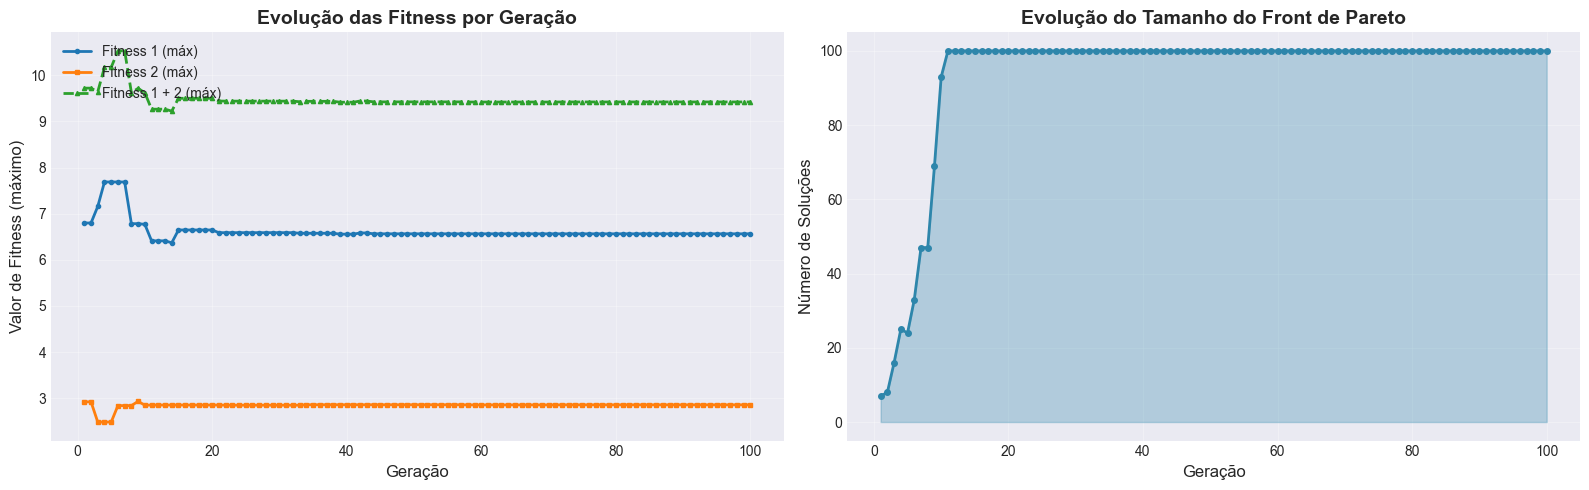


✅ Gráficos de progresso gerados com sucesso!


100%|██████████| 100/100 [01:00<00:00,  1.65it/s]


✅ Otimização concluída!
Registros únicos no dataframe: 100


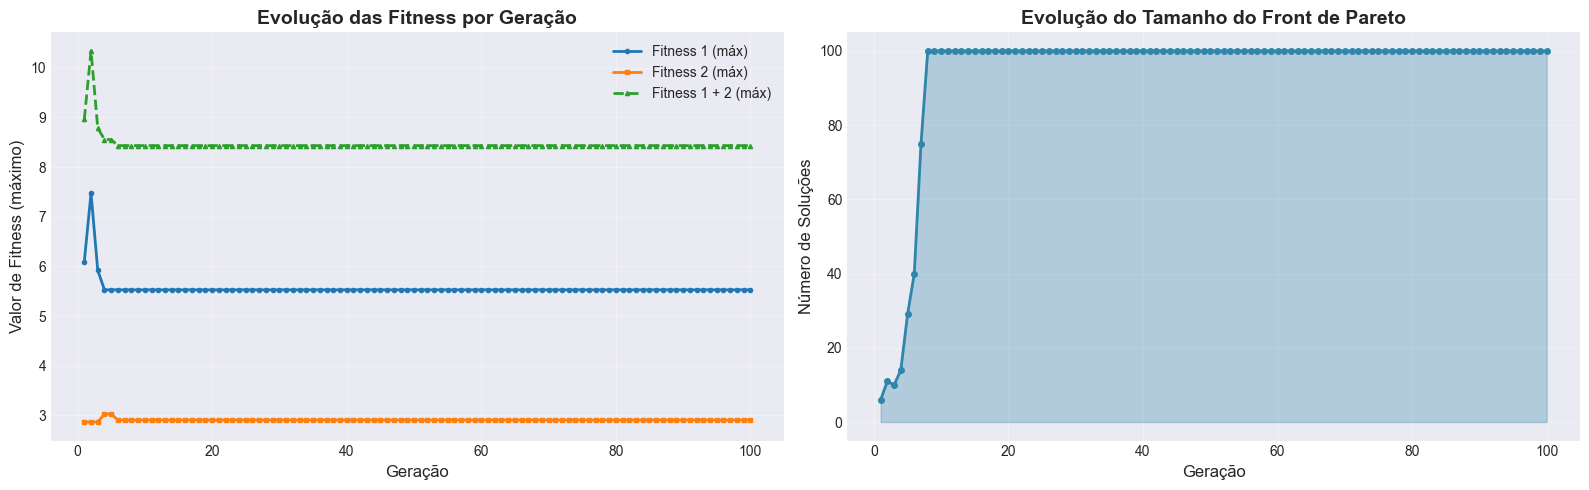


✅ Gráficos de progresso gerados com sucesso!


100%|██████████| 100/100 [01:21<00:00,  1.23it/s]


✅ Otimização concluída!
Soluções únicas no front de Pareto: 100


In [9]:
### NSGA2 - Original
config['n_generations'] = 100

df_bbob16_aux = df_bbob16_previsao.copy()
df_bbob16_aux['fitness1'] = df_bbob16_aux['f1_original']
df_bbob16_aux['fitness2'] = df_bbob16_aux['f2_original']

df_pareto_my, _, _ = run_my_nsga2(config, df_bbob16_aux)
df_pareto_my['f1'] = df_pareto_my['f1_original']
df_pareto_my['f2'] = df_pareto_my['f2_original']


### NSGA2 - Surrogate
df_bbob16_aux = df_bbob16_previsao.copy()
df_bbob16_aux['fitness1'] = df_bbob16_aux['f1_predicted']
df_bbob16_aux['fitness2'] = df_bbob16_aux['f2_predicted']

df_pareto_my2, _, _ = run_my_nsga2(config, df_bbob16_aux)
df_pareto_my2['f1'] = df_pareto_my2['f1_original']
df_pareto_my2['f2'] = df_pareto_my2['f2_original']


### UA-SA-NSGA2
config['utiliza_ds_niching'] = False
df_pareto_ua_sa, history = run_my_uasa_nsga2(config, df_landscape_bbob16, save_history=True)
df_pareto_ua_sa.drop_duplicates(subset=['x_1_landscape', 'x_2_landscape'], inplace=True)
df_pareto_ua_sa = (df_pareto_ua_sa[['x_1_landscape', 'x_2_landscape', 'f1_original', 'f2_original']].
                            rename(columns={'x_1_landscape': 'x_1', 
                                            'x_2_landscape': 'x_2', 
                                            'f1_original': 'f1', 
                                            'f2_original': 'f2'
                                   })
)

In [12]:
display(df_pareto_ua_sa.head(3))
display(df_pareto_my.head(3))
display(df_pareto_my2.head(3))

df_pareto_bbob16 = find_pareto_front(df_bbob16, minimize=True, fitness1='f1', fitness2='f2')
display(df_pareto_bbob16.head(3))

,x_1,x_2,f1,f2
0,-1.596597,-3.698699,0.295725,2.944697
1,-1.606607,-3.688689,0.272536,2.939066
2,-1.596597,-3.688689,0.273807,2.937465


,x_1,x_2,fitness1,fitness2,x_1_landscape,x_2_landscape,f1,f2,f1_original,f2_original,f1_predicted,f2_predicted,mapping_success
0,-3.688075,0.074486,6.563362,0.100000,-3.688689,0.065065,6.563362,0.100000,6.563362,0.100000,6.514869,0.074175,True
1,-3.692668,0.071136,6.563362,0.100000,-3.688689,0.065065,6.563362,0.100000,6.563362,0.100000,6.514869,0.074175,True
2,-1.534254,-3.542758,0.100000,2.857431,-1.526527,-3.538539,0.100000,2.857431,0.100000,2.857431,0.647969,2.930017,True


,x_1,x_2,fitness1,fitness2,x_1_landscape,x_2_landscape,f1,f2,f1_original,f2_original,f1_predicted,f2_predicted,mapping_success
0,-3.692924,-3.992682,5.528461,0.336264,-3.688689,-3.988989,6.446917,0.866278,6.446917,0.866278,5.528461,0.336264,True
1,-3.695915,-3.982252,5.528461,0.336264,-3.698699,-3.978979,6.438333,0.858923,6.438333,0.858923,5.528461,0.336264,True
2,-1.599453,-3.687519,0.190426,2.904361,-1.596597,-3.688689,0.273807,2.937465,0.273807,2.937465,0.190426,2.904361,True


Encontrando fronteira de Pareto (algoritmo otimizado)...
Total de pontos no espaço de busca: 1,000,000
✅ Fronteira de Pareto encontrada!
Fronteira de Pareto contém 719 pontos.
Isso representa 0.0719% do espaço de busca.


,x_1,x_2,f1,f2,aux
146347,-1.526527,-3.538539,0.100000,2.857431,1
147348,-1.516517,-3.528529,0.100267,2.854049,1
147349,-1.506507,-3.528529,0.101310,2.852445,1


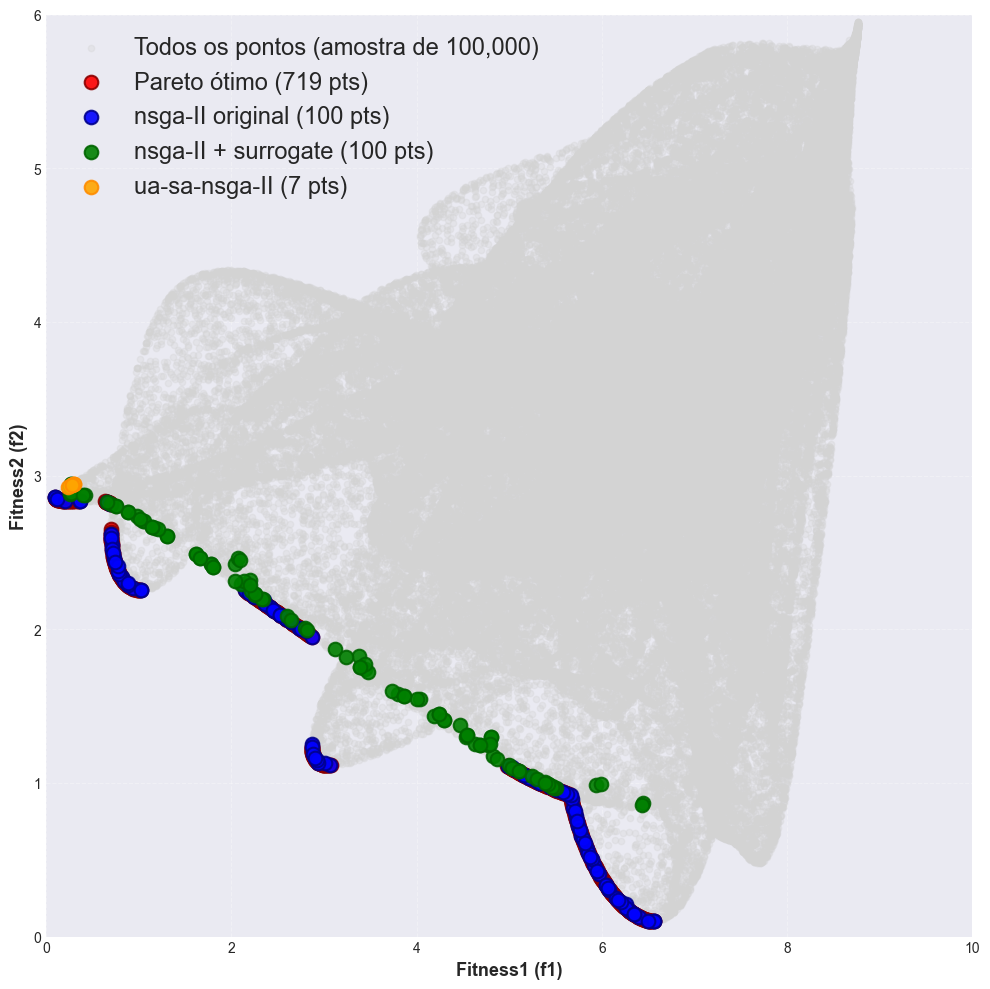

In [13]:
# Plota fronteira de Pareto real
fig_front = display_pareto_fronts3(df_bbob16, 
                                  [df_pareto_bbob16, df_pareto_my, df_pareto_my2, df_pareto_ua_sa], 
                                   fitness1='f1', fitness2='f2', 
                                   front_names=['Pareto ótimo', 'nsga-II original', 'nsga-II + surrogate', 'ua-sa-nsga-II'], 
                                   sample_size=100_000)
#fig_front.savefig('data/figures/nb1_front_verdadeiro_problema1.jpg', dpi=150, bbox_inches='tight')

#### processamento original + gifs

In [ ]:
#df_pareto_real = find_pareto_front(df_bbob16, minimize=True, fitness1='f1', fitness2='f2')
#
#df_pareto_real = df[df.registro.isin(df_pareto_real.registro.unique())]
##df_pareto_my = df[df.registro.isin(df_pareto_my.registro.unique())]
#df_pareto_ua_sa = df[df.registro.isin(df_pareto_ua_sa.registro.unique())]
##df_pareto_ua_sa_p40 = df[df.registro.isin(df_pareto_ua_sa_p40.registro.unique())]
##df_pareto_ua_sa_ds_niching = df[df.registro.isin(df_pareto_ua_sa_ds_niching.registro.unique())]
#
## convergencia entre resultados
#fig = display_pareto_fronts3(df, [df_pareto_real, df_pareto_my, df_pareto_ua_sa],#, df_pareto_ua_sa_p40],
#                       front_names=['Pareto Real', 'NSGA-II', 'UA-SA-NSGA-II'], sample_size=1000000,
#                       front_colors=['red', 'blue', 'orange'])
#fig.savefig('data/figures/nb5_pareto_ua_saea_problema1.jpg', dpi=150, bbox_inches='tight')
#
#fig_landscape_p1 = display_fitness_landscape_with_paretos(df, [df_pareto_real, df_pareto_my, df_pareto_ua_sa], 
#                                                          front_colors=['red', 'blue', 'orange'], 
#                                                          n_regioes=5, show_error_subplot=True)
#fig_landscape_p1.savefig('data/figures/nb5_landscape_ua_saea_problema1.jpg', dpi=150, bbox_inches='tight')
#
#print('===================== UA-SA-NSGA-II =====================')
#gamma_results = calculate_gamma_convergence_metric(df, df_pareto_real, df_pareto_ua_sa)
#print_gamma_metric(gamma_results)
#
#fitness_sum_results = calculate_fitness_sum_statistics(df, df_pareto_ua_sa)
#print_fitness_sum_statistics(fitness_sum_results)
#
#delta_results = calculate_delta_diversity_metric(df, df_pareto_real, df_pareto_ua_sa)
#print_delta_metric(delta_results)
#
##print('===================== gamma ua-sa-nsga2 (percentil 40) =====================')
##gamma_results = calculate_gamma_convergence_metric(df, df_pareto_real, df_pareto_ua_sa_p40)
##print_gamma_metric(gamma_results)
#
##print('===================== gamma ua-sa-nsga2 com niching =====================')
##gamma_results = calculate_gamma_convergence_metric(df, df_pareto_real, df_pareto_ua_sa_ds_niching)
##print_gamma_metric(gamma_results)
#
#print('\n===================== NSGA-II =====================')
#gamma_results = calculate_gamma_convergence_metric(df, df_pareto_real, df_pareto_my)
#print_gamma_metric(gamma_results)
#
#fitness_sum_results = calculate_fitness_sum_statistics(df, df_pareto_my)
#print_fitness_sum_statistics(fitness_sum_results)
#
#delta_results = calculate_delta_diversity_metric(df, df_pareto_real, df_pareto_my)
#print_delta_metric(delta_results)

In [ ]:
#if salva_gifs:
#    # Gerar GIF com a evolução das populações
#    caminho_gif = gerar_gif_evolucao_nsga2(
#        df_landscape=df,  # Mesmo dataframe usado acima
#        history=history,
#        nome_arquivo='gif_pareto_p1.gif',
#        fps=5,  # Ajuste a velocidade conforme preferir
#        output_dir='data/gifs'
#    )
#
#    print(f"GIF salvo em: {caminho_gif}")


#    # Gerar GIF com a evolução das populações
#    caminho_gif = gerar_gif_evolucao_nsga2(
#        df_landscape=df,  # Mesmo dataframe usado acima
#        history=history_niching,
#        nome_arquivo='gif_pareto_p1_ds_niching.gif',
#        fps=5,  # Ajuste a velocidade conforme preferir
#        output_dir='data/gifs'
#    )
#
#    print(f"GIF salvo em: {caminho_gif}")

In [ ]:
#df_history = history_to_dataframe(history).drop(columns=['id_solucao'])
#df_history = df_history.sort_values(by=['geracao','genotipo'])
#df_history['id_solucao'] = df_history.groupby(['geracao']).cumcount() + 1
#display_evolution_of_genotypes(df_history)

In [ ]:
#df_history = history_to_dataframe(history_niching).drop(columns=['id_solucao'])
#df_history = df_history.sort_values(by=['geracao','genotipo'])
#df_history['id_solucao'] = df_history.groupby(['geracao']).cumcount() + 1
#display_evolution_of_genotypes(df_history)

#### melhores solucoes

In [ ]:
#df_pareto_my, _, _, _  = run_my_nsga2(config, df_predicted)
#
#config['n_generations'] = 40
#config['utiliza_ds_niching'] = False
#df_pareto_ua_sa, history = run_my_uasa_nsga2(config, df_landscape1, save_history=True)

#config['n_generations'] = 56
#config['utiliza_ds_niching'] = True
#df_pareto_ua_sa_ds_niching, history_niching = run_my_uasa_nsga2(config, df_landscape1, save_history=True)

In [ ]:
#df_pareto_real = find_pareto_front(df)
#
#df_pareto_real = df[df.registro.isin(df_pareto_real.registro.unique())]
#df_pareto_my = df[df.registro.isin(df_pareto_my.registro.unique())]
#df_pareto_ua_sa = df[df.registro.isin(df_pareto_ua_sa.registro.unique())]
##df_pareto_ua_sa_ds_niching = df[df.registro.isin(df_pareto_ua_sa_ds_niching.registro.unique())]
#
## convergencia entre resultados
#fig = display_pareto_fronts3(df, [df_pareto_real, df_pareto_my, df_pareto_ua_sa],#, df_pareto_ua_sa_ds_niching], 
#                       front_names=['Pareto Real', 'NSGA-II', 'UA-SA-NSGA-II'], sample_size=1000000,
#                       front_colors=['red', 'blue', 'orange'])
#fig.savefig('data/figures/nb5_pareto_best_ua_saea_problema1.jpg', dpi=150, bbox_inches='tight')
#
#fig_landscape_p1_best = display_fitness_landscape_with_paretos(df, [df_pareto_real, df_pareto_my, df_pareto_ua_sa], 
#                                                               front_colors=['red', 'blue', 'orange'], 
#                                                               n_regioes=5, show_error_subplot=True)
#fig_landscape_p1_best.savefig('data/figures/nb5_landscape_best_ua_saea_problema1.jpg', dpi=150, bbox_inches='tight')
#
#print('===================== UA-SA-NSGA-II =====================')
#gamma_results = calculate_gamma_convergence_metric(df, df_pareto_real, df_pareto_ua_sa)
#print_gamma_metric(gamma_results)
#
#fitness_sum_results = calculate_fitness_sum_statistics(df, df_pareto_ua_sa)
#print_fitness_sum_statistics(fitness_sum_results)
#
#delta_results = calculate_delta_diversity_metric(df, df_pareto_real, df_pareto_ua_sa)
#print_delta_metric(delta_results)
#
##print('===================== gamma ua-sa-nsga2 com niching =====================')
##gamma_results = calculate_gamma_convergence_metric(df, df_pareto_real, df_pareto_ua_sa_ds_niching)
##print_gamma_metric(gamma_results)
#
#print('\n===================== NSGA-II =====================')
#gamma_results = calculate_gamma_convergence_metric(df, df_pareto_real, df_pareto_my)
#print_gamma_metric(gamma_results)
#
#fitness_sum_results = calculate_fitness_sum_statistics(df, df_pareto_my)
#print_fitness_sum_statistics(fitness_sum_results)
#
#delta_results = calculate_delta_diversity_metric(df, df_pareto_real, df_pareto_my)
#print_delta_metric(delta_results)

#### Landscape Previsto

In [ ]:
#df_pareto_real = find_pareto_front(df_predicted)
#
#df_pareto_real = df_predicted[df_predicted.registro.isin(df_pareto_real.registro.unique())]
#df_pareto_my = df_predicted[df_predicted.registro.isin(df_pareto_my.registro.unique())]
#df_pareto_ua_sa = df_predicted[df_predicted.registro.isin(df_pareto_ua_sa.registro.unique())]
##df_pareto_ua_sa_ds_niching = df_predicted[df_predicted.registro.isin(df_pareto_ua_sa_ds_niching.registro.unique())]
#
## convergencia entre resultados
#fig = display_pareto_fronts3(df_predicted, [df_pareto_real, df_pareto_my, df_pareto_ua_sa],#, df_pareto_ua_sa_ds_niching],
#                       front_names=['Pareto Surrogate', 'NSGA-II', 'UA-SA-NSGA-II'], sample_size=1000000,
#                       front_colors=['red', 'blue', 'orange'])
#
#
#print('===================== UA-SA-NSGA-II =====================')
#gamma_results = calculate_gamma_convergence_metric(df_predicted, df_pareto_real, df_pareto_ua_sa)
#print_gamma_metric(gamma_results)
#
#fitness_sum_results = calculate_fitness_sum_statistics(df_predicted, df_pareto_ua_sa)
#print_fitness_sum_statistics(fitness_sum_results)
#
#delta_results = calculate_delta_diversity_metric(df_predicted, df_pareto_real, df_pareto_ua_sa)
#print_delta_metric(delta_results)
#
#print('\n===================== NSGA-II =====================')
#gamma_results = calculate_gamma_convergence_metric(df_predicted, df_pareto_real, df_pareto_my)
#print_gamma_metric(gamma_results)
#
#fitness_sum_results = calculate_fitness_sum_statistics(df_predicted, df_pareto_my)
#print_fitness_sum_statistics(fitness_sum_results)
#
#delta_results = calculate_delta_diversity_metric(df_predicted, df_pareto_real, df_pareto_my)
#print_delta_metric(delta_results)

# MMF4

In [22]:
config['limite_inferior'] = np.array([-1, 0])
config['limite_superior'] = np.array([ 1, 2])

In [23]:
decision_variables = ['x_1', 'x_2']

df_landscape_mmf4 = create_landscape_from_predictions(
    df_previsao=df_mmf4_previsao,
    df_mcmc=df_mcmc_mmf4,
    decision_variables=decision_variables
)

print(df_landscape_mmf4.shape)
df_landscape_mmf4

(980000, 10)


,x_1,x_2,f1,f2,f1_original,f2_original,f1_predicted,f2_predicted,fitness1,fitness2
0,-1.0,0.000000,0.992287,-0.224668,1.0,2.960407e-31,0.915833,-0.161700,"[0.872, 1.064, 1.031, 0.836, 1.164, 1.091, 0.9...","[-0.319, 0.397, 0.272, -0.45, 0.769, 0.496, -0..."
1,-1.0,0.002002,0.931919,-0.229068,1.0,7.911394e-05,0.915833,-0.161700,"[0.872, 1.064, 1.031, 0.836, 1.164, 1.091, 0.9...","[-0.319, 0.397, 0.272, -0.45, 0.769, 0.496, -0..."
2,-1.0,0.004004,1.182322,0.331255,1.0,3.164433e-04,0.915833,-0.161700,"[0.872, 1.064, 1.031, 0.836, 1.164, 1.091, 0.9...","[-0.319, 0.397, 0.272, -0.45, 0.769, 0.496, -0..."
3,-1.0,0.006006,0.956288,0.370965,1.0,7.119504e-04,0.915833,-0.161700,"[0.872, 1.064, 1.031, 0.836, 1.164, 1.091, 0.9...","[-0.319, 0.397, 0.272, -0.45, 0.769, 0.496, -0..."
4,-1.0,0.010010,1.208606,-0.309761,1.0,1.977223e-03,0.976595,-0.189907,"[0.933, 1.125, 1.091, 0.897, 1.225, 1.151, 0.9...","[-0.347, 0.369, 0.244, -0.479, 0.74, 0.467, -0..."
...,...,...,...,...,...,...,...,...,...,...
979995,1.0,1.991992,1.100601,-0.330231,1.0,1.265573e-03,1.076096,-0.299136,"[1.24, 0.995, 1.216, 1.134, 0.926, 1.111, 1.21...","[0.275, -0.515, 0.204, -0.062, -0.734, -0.093,..."
979996,1.0,1.993994,1.100601,-0.330785,1.0,7.119504e-04,0.998398,-0.099818,"[1.162, 0.918, 1.138, 1.056, 0.848, 1.034, 1.1...","[0.474, -0.316, 0.404, 0.137, -0.534, 0.106, 0..."
979997,1.0,1.995996,1.100601,-0.331180,1.0,3.164433e-04,0.998398,-0.099818,"[1.162, 0.918, 1.138, 1.056, 0.848, 1.034, 1.1...","[0.474, -0.316, 0.404, 0.137, -0.534, 0.106, 0..."
979998,1.0,1.997998,0.900398,-0.331418,1.0,7.911394e-05,0.998398,-0.099818,"[1.162, 0.918, 1.138, 1.056, 0.848, 1.034, 1.1...","[0.474, -0.316, 0.404, 0.137, -0.534, 0.106, 0..."


100%|██████████| 100/100 [01:08<00:00,  1.45it/s]


✅ Otimização concluída!
Registros únicos no dataframe: 100


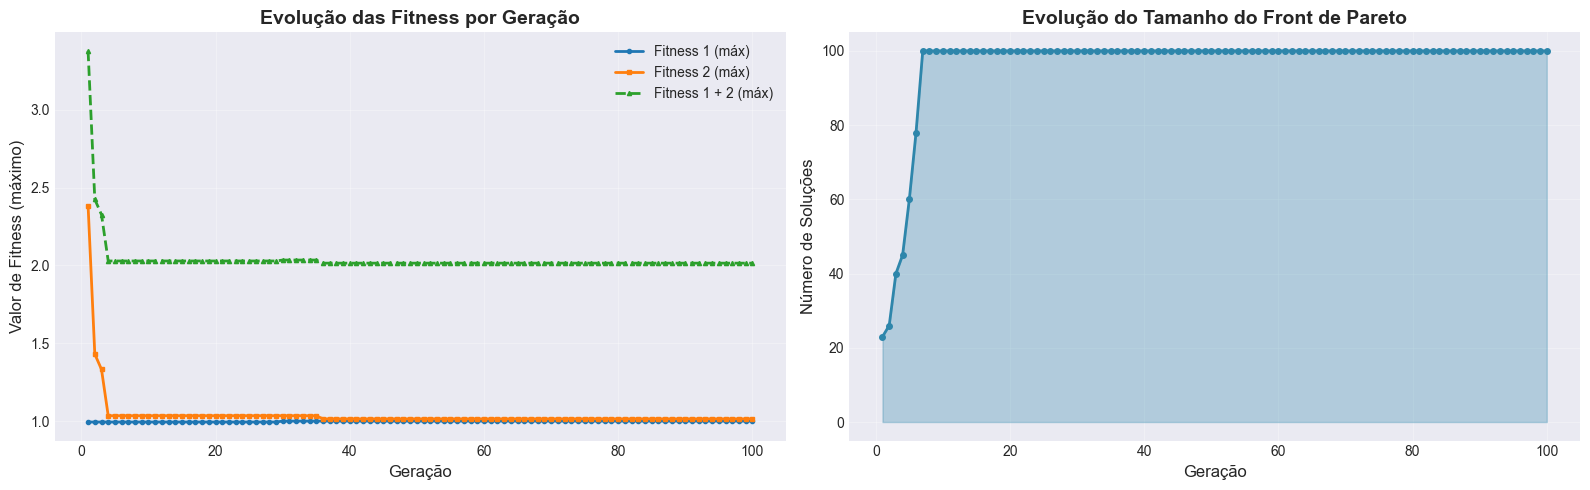


✅ Gráficos de progresso gerados com sucesso!


100%|██████████| 100/100 [01:05<00:00,  1.54it/s]


✅ Otimização concluída!
Registros únicos no dataframe: 100


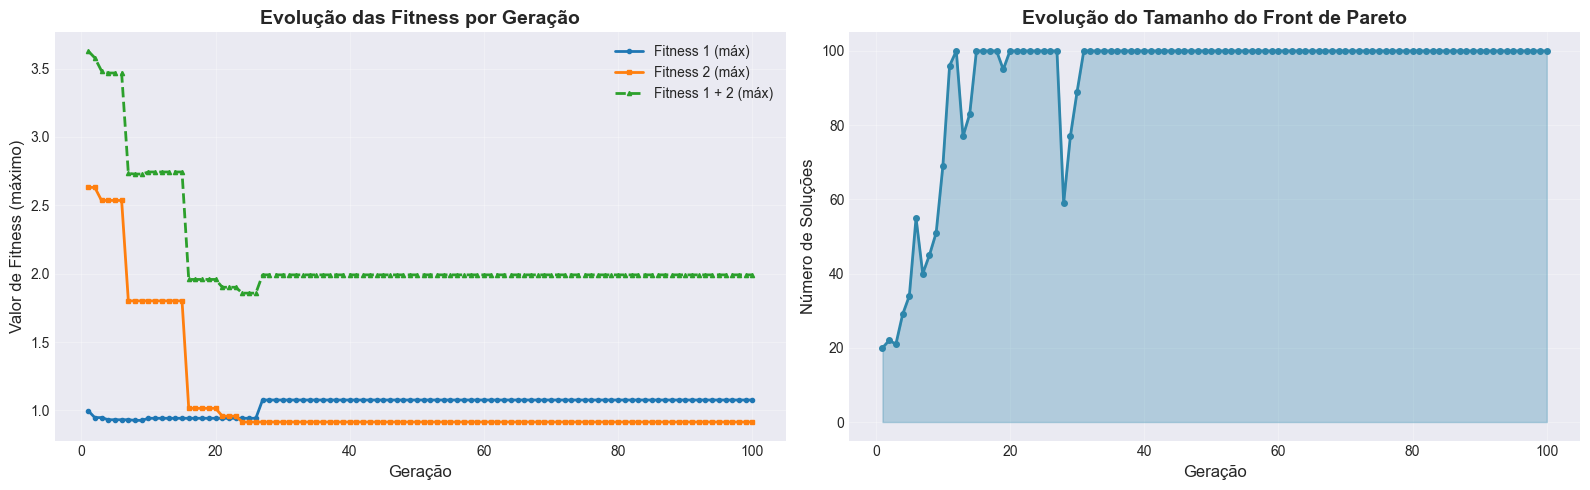


✅ Gráficos de progresso gerados com sucesso!


100%|██████████| 100/100 [01:20<00:00,  1.25it/s]


✅ Otimização concluída!
Soluções únicas no front de Pareto: 100


In [24]:
### NSGA2 - Original
config['n_generations'] = 100

df_mmf4_aux = df_mmf4_previsao.copy()
df_mmf4_aux['fitness1'] = df_mmf4_aux['f1_original']
df_mmf4_aux['fitness2'] = df_mmf4_aux['f2_original']

df_pareto_my, _, _ = run_my_nsga2(config, df_mmf4_aux)
df_pareto_my['f1'] = df_pareto_my['f1_original']
df_pareto_my['f2'] = df_pareto_my['f2_original']


### NSGA2 - Surrogate
df_mmf4_aux = df_mmf4_previsao.copy()
df_mmf4_aux['fitness1'] = df_mmf4_aux['f1_predicted']
df_mmf4_aux['fitness2'] = df_mmf4_aux['f2_predicted']

df_pareto_my2, _, _ = run_my_nsga2(config, df_mmf4_aux)
df_pareto_my2['f1'] = df_pareto_my2['f1_original']
df_pareto_my2['f2'] = df_pareto_my2['f2_original']


### UA-SA-NSGA2
config['utiliza_ds_niching'] = False
df_pareto_ua_sa, history = run_my_uasa_nsga2(config, df_landscape_mmf4, save_history=True)
df_pareto_ua_sa.drop_duplicates(subset=['x_1_landscape', 'x_2_landscape'], inplace=True)
df_pareto_ua_sa = (df_pareto_ua_sa[['x_1_landscape', 'x_2_landscape', 'f1_original', 'f2_original']].
                            rename(columns={'x_1_landscape': 'x_1', 
                                            'x_2_landscape': 'x_2', 
                                            'f1_original': 'f1', 
                                            'f2_original': 'f2'
                                   })
)

In [25]:
display(df_pareto_ua_sa.head(3))
display(df_pareto_my.head(3))
display(df_pareto_my2.head(3))

df_pareto_mmf4 = find_pareto_front(df_mmf4, minimize=True, fitness1='f1', fitness2='f2')
display(df_pareto_mmf4.head(3))

,x_1,x_2,f1,f2
0,0.215215,0.586587,0.215215,0.983836
1,0.215215,0.576577,0.215215,1.001072
7,0.195195,0.586587,0.195195,0.964321


,x_1,x_2,fitness1,fitness2,x_1_landscape,x_2_landscape,f1,f2,f1_original,f2_original,f1_predicted,f2_predicted,mapping_success
0,-0.998465,1.002759,1.000000,0.000178,-1.000000,0.996997,1.000000,0.000178,1.000000,0.000178,1.008031,0.028811,True
1,-0.998465,1.002759,1.000000,0.000178,-1.000000,0.996997,1.000000,0.000178,1.000000,0.000178,1.008031,0.028811,True
2,-0.003194,1.981996,0.001001,1.014534,-0.001001,1.975976,0.001001,1.014534,0.001001,1.014534,-0.027999,1.015153,True


,x_1,x_2,fitness1,fitness2,x_1_landscape,x_2_landscape,f1,f2,f1_original,f2_original,f1_predicted,f2_predicted,mapping_success
0,1.00000,1.988017,1.076096,-0.299136,0.995996,1.985986,0.995996,0.021918,0.995996,0.021918,1.076096,-0.299136,True
1,1.00000,1.992756,1.076096,-0.299136,0.995996,1.985986,0.995996,0.021918,0.995996,0.021918,1.076096,-0.299136,True
2,0.00488,2.000000,-0.053714,0.915014,-0.003003,1.995996,0.003003,1.003553,0.003003,1.003553,-0.053714,0.915014,True


Encontrando fronteira de Pareto (algoritmo otimizado)...
Total de pontos no espaço de busca: 1,000,000
✅ Fronteira de Pareto encontrada!
Fronteira de Pareto contém 1,019 pontos.
Isso representa 0.1019% do espaço de busca.


,x_1,x_2,f1,f2,aux
501499,-0.001001,1.003003,0.001001,0.999999,1
501500,0.001001,1.003003,0.001001,0.999999,1
504498,-0.003003,1.009009,0.003003,0.999995,1


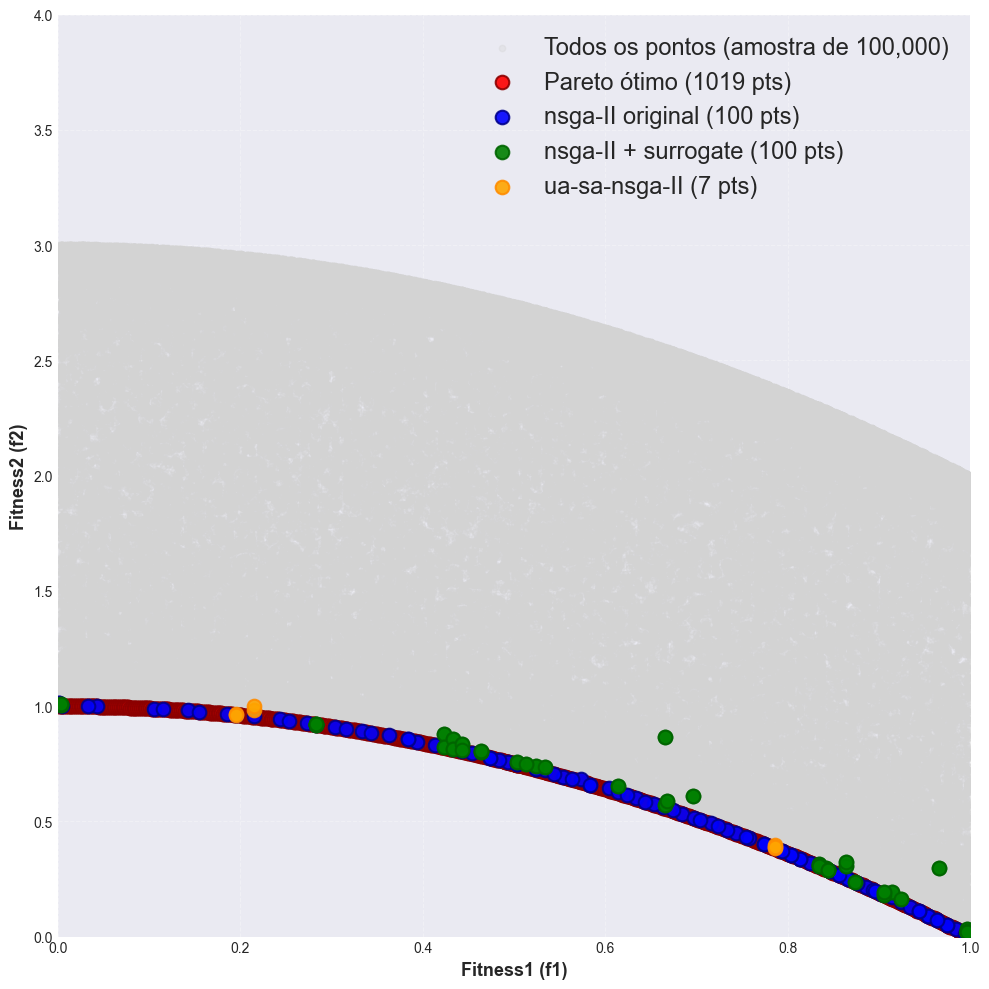

In [26]:
# Plota fronteira de Pareto real
fig_front = display_pareto_fronts3(df_mmf4, 
                                  [df_pareto_mmf4, df_pareto_my, df_pareto_my2, df_pareto_ua_sa], 
                                   fitness1='f1', fitness2='f2', 
                                   front_names=['Pareto ótimo', 'nsga-II original', 'nsga-II + surrogate', 'ua-sa-nsga-II'], 
                                   sample_size=100_000)
#fig_front.savefig('data/figures/nb1_front_verdadeiro_problema1.jpg', dpi=150, bbox_inches='tight')

# MMF1

In [29]:
config['limite_inferior'] = np.array([1, -1])
config['limite_superior'] = np.array([3,  1])

In [30]:
decision_variables = ['x_1', 'x_2']

df_landscape_mmf1 = create_landscape_from_predictions(
    df_previsao=df_mmf1_previsao,
    df_mcmc=df_mcmc_mmf1,
    decision_variables=decision_variables
)

print(df_landscape_mmf1.shape)
df_landscape_mmf1

(980000, 10)


,x_1,x_2,f1,f2,f1_original,f2_original,f1_predicted,f2_predicted,fitness1,fitness2
0,1.0,-1.000000,0.992287,1.730255,1.0,2.000000,0.915833,2.209586,"[0.872, 1.064, 1.031, 0.836, 1.164, 1.091, 0.9...","[2.131, 2.528, 3.063, 1.942, 3.295, 3.052, 2.5..."
1,1.0,-0.997998,0.931919,1.716878,1.0,1.992000,0.915833,2.209586,"[0.872, 1.064, 1.031, 0.836, 1.164, 1.091, 0.9...","[2.131, 2.528, 3.063, 1.942, 3.295, 3.052, 2.5..."
2,1.0,-0.995996,1.182322,2.381354,1.0,1.984016,0.915833,2.209586,"[0.872, 1.064, 1.031, 0.836, 1.164, 1.091, 0.9...","[2.131, 2.528, 3.063, 1.942, 3.295, 3.052, 2.5..."
3,1.0,-0.993994,0.956288,2.420588,1.0,1.976048,0.915833,2.209586,"[0.872, 1.064, 1.031, 0.836, 1.164, 1.091, 0.9...","[2.131, 2.528, 3.063, 1.942, 3.295, 3.052, 2.5..."
4,1.0,-0.989990,1.208606,1.585876,1.0,1.960160,0.976595,2.154911,"[0.933, 1.125, 1.091, 0.897, 1.225, 1.151, 0.9...","[2.076, 2.473, 3.008, 1.888, 3.24, 2.998, 2.53..."
...,...,...,...,...,...,...,...,...,...,...
979995,3.0,0.991992,1.100601,1.570089,1.0,1.968096,1.076096,1.252732,"[1.24, 0.995, 1.216, 1.134, 0.926, 1.111, 1.21...","[1.997, 1.006, 2.086, 0.978, 0.52, 1.723, 1.63..."
979996,3.0,0.993994,1.100601,1.578041,1.0,1.976048,0.998398,1.492884,"[1.162, 0.918, 1.138, 1.056, 0.848, 1.034, 1.1...","[2.237, 1.246, 2.326, 1.218, 0.76, 1.963, 1.87..."
979997,3.0,0.995996,1.100601,1.586009,1.0,1.984016,0.998398,1.492884,"[1.162, 0.918, 1.138, 1.056, 0.848, 1.034, 1.1...","[2.237, 1.246, 2.326, 1.218, 0.76, 1.963, 1.87..."
979998,3.0,0.997998,0.900398,1.593993,1.0,1.992000,0.998398,1.492884,"[1.162, 0.918, 1.138, 1.056, 0.848, 1.034, 1.1...","[2.237, 1.246, 2.326, 1.218, 0.76, 1.963, 1.87..."


100%|██████████| 100/100 [01:02<00:00,  1.59it/s]


✅ Otimização concluída!
Registros únicos no dataframe: 100


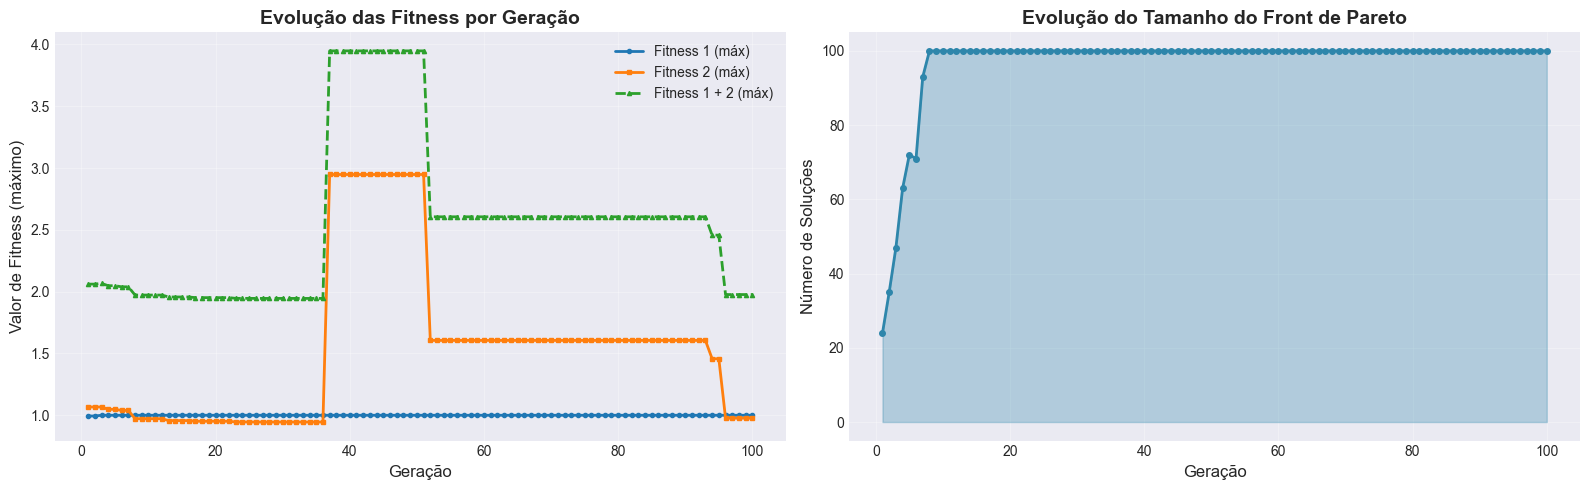


✅ Gráficos de progresso gerados com sucesso!


100%|██████████| 100/100 [01:03<00:00,  1.56it/s]


✅ Otimização concluída!
Registros únicos no dataframe: 100


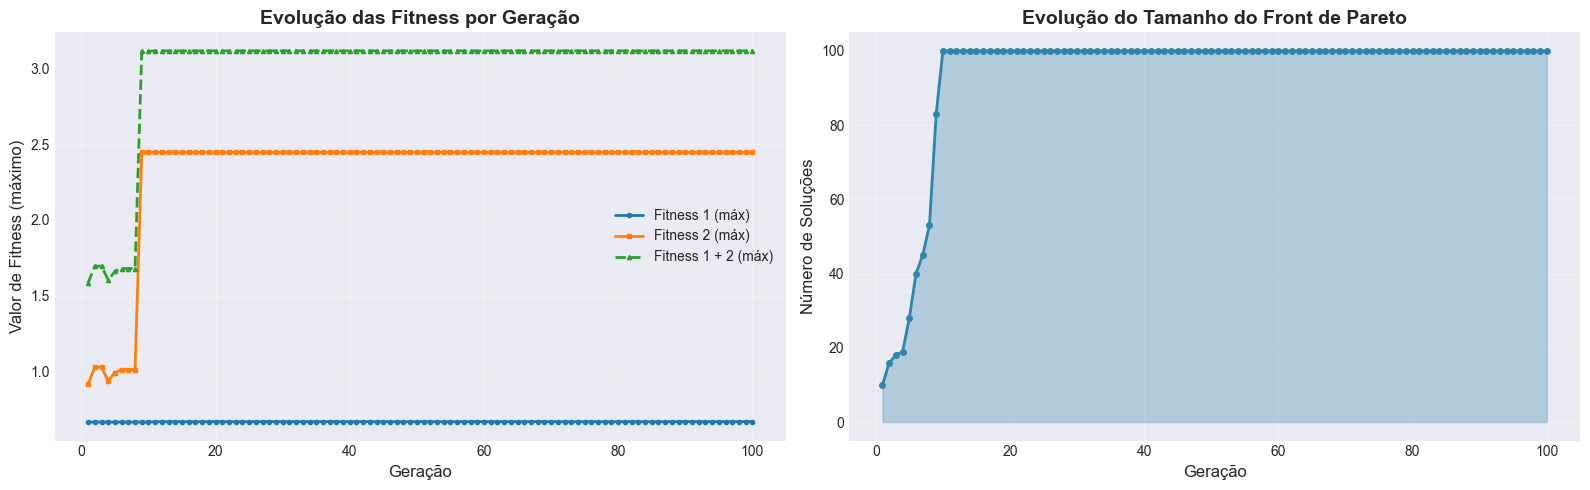


✅ Gráficos de progresso gerados com sucesso!


  0%|          | 0/100 [00:00<?, ?it/s]/Users/gmello/Documents/python_venvs/mestrado_estatistica/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
100%|██████████| 100/100 [01:17<00:00,  1.29it/s]


✅ Otimização concluída!
Soluções únicas no front de Pareto: 100


In [31]:
### NSGA2 - Original
config['n_generations'] = 100

df_mmf1_aux = df_mmf1_previsao.copy()
df_mmf1_aux['fitness1'] = df_mmf1_aux['f1_original']
df_mmf1_aux['fitness2'] = df_mmf1_aux['f2_original']

df_pareto_my, _, _ = run_my_nsga2(config, df_mmf1_aux)
df_pareto_my['f1'] = df_pareto_my['f1_original']
df_pareto_my['f2'] = df_pareto_my['f2_original']


### NSGA2 - Surrogate
df_mmf1_aux = df_mmf1_previsao.copy()
df_mmf1_aux['fitness1'] = df_mmf1_aux['f1_predicted']
df_mmf1_aux['fitness2'] = df_mmf1_aux['f2_predicted']

df_pareto_my2, _, _ = run_my_nsga2(config, df_mmf1_aux)
df_pareto_my2['f1'] = df_pareto_my2['f1_original']
df_pareto_my2['f2'] = df_pareto_my2['f2_original']


### UA-SA-NSGA2
config['utiliza_ds_niching'] = False
df_pareto_ua_sa, history = run_my_uasa_nsga2(config, df_landscape_mmf1, save_history=True)
df_pareto_ua_sa.drop_duplicates(subset=['x_1_landscape', 'x_2_landscape'], inplace=True)
df_pareto_ua_sa = (df_pareto_ua_sa[['x_1_landscape', 'x_2_landscape', 'f1_original', 'f2_original']].
                            rename(columns={'x_1_landscape': 'x_1', 
                                            'x_2_landscape': 'x_2', 
                                            'f1_original': 'f1', 
                                            'f2_original': 'f2'
                                   })
)

In [32]:
display(df_pareto_ua_sa.head(3))
display(df_pareto_my.head(3))
display(df_pareto_my2.head(3))

df_pareto_mmf1 = find_pareto_front(df_mmf1, minimize=True, fitness1='f1', fitness2='f2')
display(df_pareto_mmf1.head(3))

,x_1,x_2,f1,f2
0,1.856857,-0.303303,0.143143,0.653267


,x_1,x_2,fitness1,fitness2,x_1_landscape,x_2_landscape,f1,f2,f1_original,f2_original,f1_predicted,f2_predicted,mapping_success
0,1.002121,-0.004717,1.000000,0.000018,1.000000,-0.003003,1.000000,0.000018,1.000000,0.000018,1.008031,0.108562,True
1,1.002121,-0.004717,1.000000,0.000018,1.000000,-0.003003,1.000000,0.000018,1.000000,0.000018,1.008031,0.108562,True
2,2.002924,0.054308,0.001001,0.976531,1.998999,0.045045,0.001001,0.976531,0.001001,0.976531,-0.007123,0.895515,True


,x_1,x_2,fitness1,fitness2,x_1_landscape,x_2_landscape,f1,f2,f1_original,f2_original,f1_predicted,f2_predicted,mapping_success
0,1.312802,-0.521062,0.669476,-0.239492,1.306306,-0.523524,0.693694,0.169685,0.693694,0.169685,0.669476,-0.239492,True
1,1.306249,-0.519152,0.669476,-0.239492,1.306306,-0.523524,0.693694,0.169685,0.693694,0.169685,0.669476,-0.239492,True
2,2.000739,-0.995323,-0.040478,2.444472,1.996997,-1.000000,0.003003,2.725302,0.003003,2.725302,-0.040478,2.444472,True


Encontrando fronteira de Pareto (algoritmo otimizado)...
Total de pontos no espaço de busca: 1,000,000
✅ Fronteira de Pareto encontrada!
Fronteira de Pareto contém 1,000 pontos.
Isso representa 0.1000% do espaço de busca.


,x_1,x_2,f1,f2,aux
490499,1.998999,-0.019019,0.001001,0.968361,1
490500,2.001001,-0.019019,0.001001,0.968361,1
471501,2.003003,-0.057057,0.003003,0.945201,1


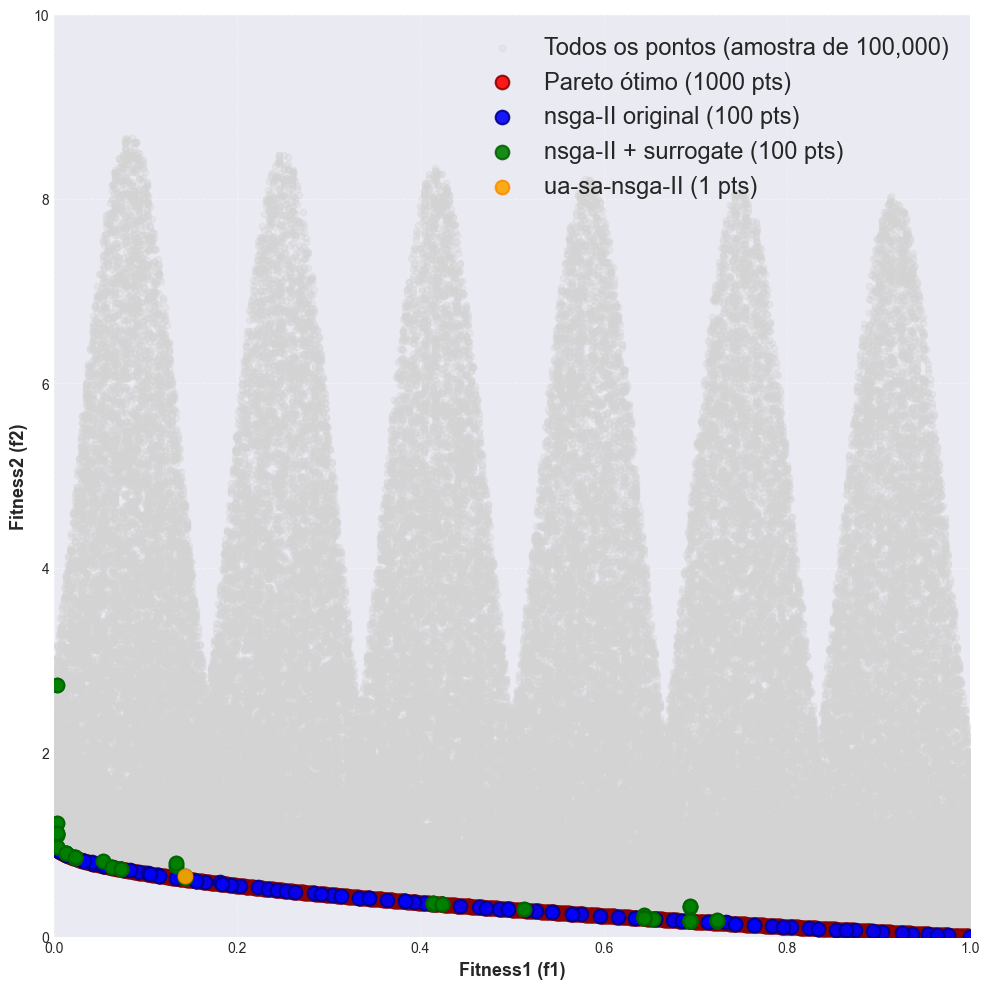

In [33]:
# Plota fronteira de Pareto real
fig_front = display_pareto_fronts3(df_mmf1, 
                                  [df_pareto_mmf1, df_pareto_my, df_pareto_my2, df_pareto_ua_sa], 
                                   fitness1='f1', fitness2='f2', 
                                   front_names=['Pareto ótimo', 'nsga-II original', 'nsga-II + surrogate', 'ua-sa-nsga-II'], 
                                   sample_size=100_000)
#fig_front.savefig('data/figures/nb1_front_verdadeiro_problema1.jpg', dpi=150, bbox_inches='tight')